In [71]:
import graphviz
import uuid

import cas
from cas.ast_node import ASTNode

In [72]:
s = 'cos(3.5x) + x^4.9 / 0.5'
e = cas.Expression.fromstr(s)

In [73]:
def gv_tree(head: ASTNode) -> graphviz.Digraph:
    tree = graphviz.Digraph()

    def traverse_tree(curr: ASTNode, parent = None):
        curr_id = gen_id()
        tree.node(curr_id, label=curr.literal())
        if parent:
            tree.edge(parent, curr_id)
        if curr.children() and len(curr.children()) > 0:
            for child in curr.children():
                traverse_tree(child, curr_id)

    def gen_id():
        length = 16
        return str(uuid.uuid4()).replace('-', '')[:length]

    traverse_tree(head)
    return tree

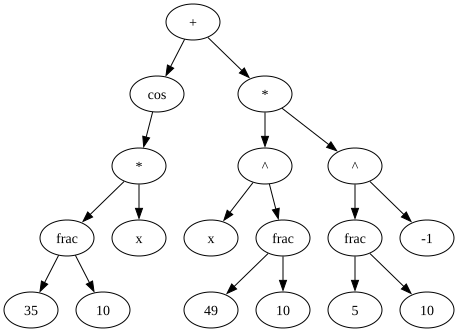

In [74]:
gv_tree(e._expression)